# Challenge Goals
---
1. Instantiate a quantum circuit with one quantum bit and one classical bit.
2. Measure the qubit and store the result in the classical bit.
3. Simulate 1,000-plus shots and plot the results on a histogram.
4. Display the state vector and Bloch sphere representation.

In [36]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
import matplotlib.pyplot as plt

In [37]:
#1.Instantiate a quantum circuit with one quantum bit and one classical bit.
qr = QuantumRegister(1)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)
circuit.h(0)#Hadamard gate

In [38]:
# 2. Measure the qubit and store the result in the classical bit.
circuit.measure(qr, cr)
simulator = Aer.get_backend('qasm_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=1024).result()

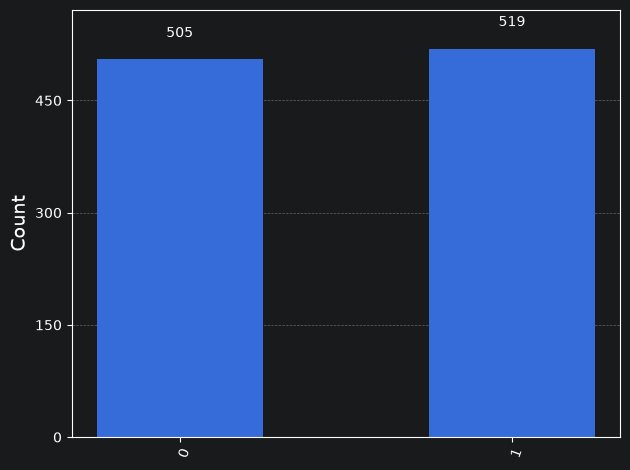

In [39]:
# 3. Simulate 1,000-plus shots and plot the results on a histogram.
plot_histogram(result.get_counts())  # View distribution.

In [40]:
# 4a. Display the state vector
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

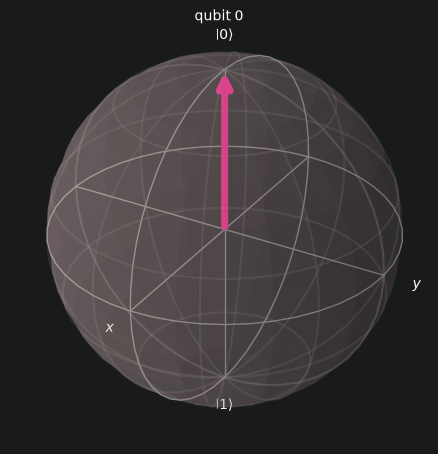

In [41]:
# 4b. Display the Bloch sphere representation.
plot_bloch_multivector(statevector)